In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate, MultiHeadAttention

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
kwh_data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/Kwh_Data_Model_Train.csv", index_col= 'datetime', parse_dates= True)
kwh_data

,temp1,humidity1,windgust1,winddir1,cloudcover1,solarradiation1,temp2,humidity2,windgust2,winddir2,cloudcover2,solarradiation2,temp3,humidity3,windgust3,winddir3,cloudcover3,solarradiation3,temp4,humidity4,windgust4,winddir4,cloudcover4,solarradiation4,temp5,humidity5,windgust5,winddir5,cloudcover5,solarradiation5,conditions_int_1,conditions_int_2,conditions_int_3,conditions_int_4,conditions_int_5,Kwh
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,5.7,80.47,17.3,240.0,0.0,0.0,6.0,75.52,21.2,240.0,0.9,0.0,5.7,78.31,20.2,240.0,0.0,0.0,5.5,84.34,21.6,240.0,0.0,0.0,0,0,0,0,0,0.0000
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,6.0,78.82,18.0,261.9,0.0,0.0,6.0,75.52,21.6,309.1,1.7,0.0,5.7,79.77,19.8,291.7,0.0,0.0,5.0,84.28,21.2,311.1,0.0,0.0,0,0,0,0,0,0.0000
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,5.6,82.35,18.9,333.0,40.0,0.0,2.3,89.61,16.2,2.0,0.0,0.0,4.3,82.60,16.0,305.0,0.0,0.0,3.8,89.49,11.8,305.0,30.0,0.0,2,2,0,0,2,0.0000
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,4.3,82.60,18.7,90.0,17.8,0.0,4.0,80.80,21.2,296.4,27.3,0.0,3.2,85.34,20.5,0.0,0.0,0.0,3.5,90.35,22.3,311.0,0.0,0.0,2,0,2,0,0,0.0000
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,3.3,93.16,18.7,90.0,19.6,0.0,3.0,93.14,20.2,294.0,28.1,0.0,2.5,94.85,19.8,286.3,0.0,0.0,2.5,93.11,22.3,306.5,0.0,0.0,2,0,2,0,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,25.7,42.86,17.6,290.0,27.5,207.0,23.1,42.02,32.4,313.0,50.0,207.0,23.7,45.57,23.4,170.0,50.0,39.0,23.5,57.88,20.9,180.0,50.0,121.0,2,2,2,2,2,0.0592
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,24.4,45.20,15.8,209.0,27.5,103.0,22.1,43.60,26.3,30.0,50.0,103.0,22.0,50.00,16.6,140.0,89.0,82.0,23.0,55.83,17.3,170.2,50.0,71.0,5,2,2,2,2,0.0085
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,22.4,50.62,5.0,304.0,30.0,9.0,21.8,48.00,17.6,42.0,66.6,9.0,21.3,52.10,5.4,356.0,41.7,51.0,22.1,58.99,15.1,0.0,50.0,44.0,5,2,2,5,2,0.0000


In [4]:
kwh_data['Kwh Target'] = kwh_data['Kwh']
kwh_data.head()

,temp1,humidity1,windgust1,winddir1,cloudcover1,solarradiation1,temp2,humidity2,windgust2,winddir2,cloudcover2,solarradiation2,temp3,humidity3,windgust3,winddir3,cloudcover3,solarradiation3,temp4,humidity4,windgust4,winddir4,cloudcover4,solarradiation4,temp5,humidity5,windgust5,winddir5,cloudcover5,solarradiation5,conditions_int_1,conditions_int_2,conditions_int_3,conditions_int_4,conditions_int_5,Kwh,Kwh Target
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,5.7,80.47,17.3,240.0,0.0,0.0,6.0,75.52,21.2,240.0,0.9,0.0,5.7,78.31,20.2,240.0,0.0,0.0,5.5,84.34,21.6,240.0,0.0,0.0,0,0,0,0,0,0.0,0.0
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,6.0,78.82,18.0,261.9,0.0,0.0,6.0,75.52,21.6,309.1,1.7,0.0,5.7,79.77,19.8,291.7,0.0,0.0,5.0,84.28,21.2,311.1,0.0,0.0,0,0,0,0,0,0.0,0.0
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,5.6,82.35,18.9,333.0,40.0,0.0,2.3,89.61,16.2,2.0,0.0,0.0,4.3,82.60,16.0,305.0,0.0,0.0,3.8,89.49,11.8,305.0,30.0,0.0,2,2,0,0,2,0.0,0.0
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,4.3,82.60,18.7,90.0,17.8,0.0,4.0,80.80,21.2,296.4,27.3,0.0,3.2,85.34,20.5,0.0,0.0,0.0,3.5,90.35,22.3,311.0,0.0,0.0,2,0,2,0,0,0.0,0.0
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,3.3,93.16,18.7,90.0,19.6,0.0,3.0,93.14,20.2,294.0,28.1,0.0,2.5,94.85,19.8,286.3,0.0,0.0,2.5,93.11,22.3,306.5,0.0,0.0,2,0,2,0,0,0.0,0.0


In [5]:
kwh_data.shape

(21983, 37)

In [6]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :kwh_data.shape[1] - 1])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.009887,0.853544,0.160899,0.243452,-1.414670,-0.710077,-0.732571,0.430338,-0.062316,0.257627,-1.415610,-0.667396,-0.893320,0.738504,0.298943,0.336897,-1.369232,-0.702416,-1.037464,0.926566,0.449868,0.513351,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.974958,0.773497,0.228552,0.417484,-1.414670,-0.710077,-0.732571,0.430338,-0.029096,0.813706,-1.392812,-0.667396,-0.893320,0.806940,0.260969,0.717556,-1.369232,-0.702416,-1.093388,0.923848,0.409202,1.028030,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-1.021530,0.944749,0.315535,0.982490,0.023965,-0.710077,-1.152691,1.100690,-0.477562,-1.657667,-1.441258,-0.667396,-1.054518,0.939595,-0.099781,0.815481,-1.369232,-0.702416,-1.227605,1.159931,-0.546449,0.983873,-0.473644,-0.706979,0.662831,0.249815,-1.367889,-1.277920,0.377153,-0.679890
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-1.172888,0.956878,0.296205,-0.948545,-0.774477,-0.710077,-0.959663,0.681542,-0.062316,0.711503,-0.663277,-0.667396,-1.181174,1.068031,0.327423,-1.430185,-1.369232,-0.702416,-1.261160,1.198900,0.521034,1.027306,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-1.289318,1.469178,0.296205,-0.948545,-0.709739,-0.710077,-1.073209,1.268635,-0.145365,0.692190,-0.640479,-0.667396,-1.261773,1.513807,0.260969,0.677796,-1.369232,-0.702416,-1.373008,1.323965,0.521034,0.994731,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890
5,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640,-1.126316,1.090774,1.977864,0.481851,-0.745705,-0.710077,-1.538748,1.594533,-1.191786,0.748522,-1.441258,-0.667396,-1.307829,1.409746,-0.507998,0.933287,-1.369232,-0.702416,-1.373008,1.323965,0.561700,0.996903,-1.435991,-0.706979,0.662831,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
6,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640,-1.207817,1.251839,0.334864,1.197050,-0.702546,-0.710077,-0.959663,0.967000,-0.087230,1.223322,1.408488,-0.667396,-1.204202,1.208186,0.260969,1.220438,-1.352558,-0.702416,-1.317084,1.338919,0.673532,1.382007,-1.419898,-0.706979,0.662831,-1.736325,-0.413791,-1.277920,-1.776342,-0.679890
7,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640,-1.044816,0.769131,0.441176,1.038117,0.358448,-0.710077,-0.732571,0.430338,0.004124,1.062372,1.408488,-0.667396,-1.008462,0.869283,0.431851,1.095269,-1.005189,-0.702416,-1.216421,1.063413,0.887028,1.237231,-1.172070,-0.706979,0.662831,0.249815,-0.413791,-1.277920,-1.776342,-0.679890
8,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949,-1.021530,0.844812,0.470170,0.903024,0.257744,-0.687358,-1.538748,1.594533,-0.029096,0.531241,0.057708,-0.644689,-1.192688,1.123343,0.431851,1.139446,-0.343797,-0.702416,-1.384192,1.195275,0.998860,1.237231,0.170066,-0.706621,0.662831,0.249815,0.540307,0.467173,0.377153,-0.542965
9,-0.844550,0.924518,0.745665,0.530576,0.058244,-0.580657,-1.009887,1.139773,0.682794,0.259345,0.139056,-0.622989,-1.039145,0.936551,0.211747,0.660000,-0.016385,-0.580352,-1.008462,1.075531,0.564759,0.778667,-0.140933,-0.543868,-1.216421,1.200260,1.181857,0.875291,0.170066,-0.516372,0.662831,0.249815,0.540307,0.467173,0.377153,-0.234996


In [7]:
df_scaled_kwh.index = kwh_data.index
df_scaled_kwh

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.009887,0.853544,0.160899,0.243452,-1.414670,-0.710077,-0.732571,0.430338,-0.062316,0.257627,-1.415610,-0.667396,-0.893320,0.738504,0.298943,0.336897,-1.369232,-0.702416,-1.037464,0.926566,0.449868,0.513351,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.974958,0.773497,0.228552,0.417484,-1.414670,-0.710077,-0.732571,0.430338,-0.029096,0.813706,-1.392812,-0.667396,-0.893320,0.806940,0.260969,0.717556,-1.369232,-0.702416,-1.093388,0.923848,0.409202,1.028030,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-1.021530,0.944749,0.315535,0.982490,0.023965,-0.710077,-1.152691,1.100690,-0.477562,-1.657667,-1.441258,-0.667396,-1.054518,0.939595,-0.099781,0.815481,-1.369232,-0.702416,-1.227605,1.159931,-0.546449,0.983873,-0.473644,-0.706979,0.662831,0.249815,-1.367889,-1.277920,0.377153,-0.679890
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-1.172888,0.956878,0.296205,-0.948545,-0.774477,-0.710077,-0.959663,0.681542,-0.062316,0.711503,-0.663277,-0.667396,-1.181174,1.068031,0.327423,-1.430185,-1.369232,-0.702416,-1.261160,1.198900,0.521034,1.027306,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-1.289318,1.469178,0.296205,-0.948545,-0.709739,-0.710077,-1.073209,1.268635,-0.145365,0.692190,-0.640479,-0.667396,-1.261773,1.513807,0.260969,0.677796,-1.369232,-0.702416,-1.373008,1.323965,0.521034,0.994731,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206,1.318702,-0.971041,0.189893,0.640784,-0.425608,0.073713,1.209067,-1.163471,0.867837,0.845091,-0.016385,0.116002,1.179227,-0.796165,0.602733,-0.178502,0.020247,-0.567112,0.975798,-0.272428,0.378703,0.079023,0.170066,-0.274270,0.662831,0.249815,0.540307,0.467173,0.377153,-0.414121
2024-07-04 20:00:00,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108,1.167343,-0.857520,0.015929,-0.002894,-0.425608,-0.320075,1.095521,-1.088301,0.361236,-1.432338,-0.016385,-0.277590,0.983486,-0.588512,-0.042820,-0.399388,1.104041,-0.417931,0.919874,-0.365320,0.012709,0.008083,0.170066,-0.453075,3.349560,0.249815,0.540307,0.467173,0.377153,-0.641731
2024-07-04 21:00:00,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603,0.934485,-0.594578,-1.027860,0.752037,-0.335694,-0.675999,1.061457,-0.878964,-0.361293,-1.335769,0.456673,-0.633336,0.902887,-0.490075,-1.106084,1.190986,-0.210407,-0.525480,0.819211,-0.222130,-0.210954,-1.223961,0.170066,-0.549630,3.349560,0.249815,0.540307,3.084813,0.377153,-0.679890


In [8]:
df_scaled_kwh = pd.concat([df_scaled_kwh, kwh_data["Kwh Target"]], axis=1)
df_scaled_kwh.head(30)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,Kwh Target
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.009887,0.853544,0.160899,0.243452,-1.414670,-0.710077,-0.732571,0.430338,-0.062316,0.257627,-1.415610,-0.667396,-0.893320,0.738504,0.298943,0.336897,-1.369232,-0.702416,-1.037464,0.926566,0.449868,0.513351,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.974958,0.773497,0.228552,0.417484,-1.414670,-0.710077,-0.732571,0.430338,-0.029096,0.813706,-1.392812,-0.667396,-0.893320,0.806940,0.260969,0.717556,-1.369232,-0.702416,-1.093388,0.923848,0.409202,1.028030,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-1.021530,0.944749,0.315535,0.982490,0.023965,-0.710077,-1.152691,1.100690,-0.477562,-1.657667,-1.441258,-0.667396,-1.054518,0.939595,-0.099781,0.815481,-1.369232,-0.702416,-1.227605,1.159931,-0.546449,0.983873,-0.473644,-0.706979,0.662831,0.249815,-1.367889,-1.277920,0.377153,-0.679890,0.0000
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-1.172888,0.956878,0.296205,-0.948545,-0.774477,-0.710077,-0.959663,0.681542,-0.062316,0.711503,-0.663277,-0.667396,-1.181174,1.068031,0.327423,-1.430185,-1.369232,-0.702416,-1.261160,1.198900,0.521034,1.027306,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-1.289318,1.469178,0.296205,-0.948545,-0.709739,-0.710077,-1.073209,1.268635,-0.145365,0.692190,-0.640479,-0.667396,-1.261773,1.513807,0.260969,0.677796,-1.369232,-0.702416,-1.373008,1.323965,0.521034,0.994731,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 05:00:00,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640,-1.126316,1.090774,1.977864,0.481851,-0.745705,-0.710077,-1.538748,1.594533,-1.191786,0.748522,-1.441258,-0.667396,-1.307829,1.409746,-0.507998,0.933287,-1.369232,-0.702416,-1.373008,1.323965,0.561700,0.996903,-1.435991,-0.706979,0.662831,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 06:00:00,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640,-1.207817,1.251839,0.334864,1.197050,-0.702546,-0.710077,-0.959663,0.967000,-0.087230,1.223322,1.408488,-0.667396,-1.204202,1.208186,0.260969,1.220438,-1.352558,-0.702416,-1.317084,1.338919,0.673532,1.382007,-1.419898,-0.706979,0.662831,-1.736325,-0.413791,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 07:00:00,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640,-1.044816,0.769131,0.441176,1.038117,0.358448,-0.710077,-0.732571,0.430338,0.004124,1.062372,1.408488,-0.667396,-1.008462,0.869283,0.431851,1.095269,-1.005189,-0.702416,-1.216421,1.063413,0.887028,1.237231,-1.172070,-0.706979,0.662831,0.249815,-0.413791,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 08:00:00,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949,-1.021530,0.844812,0.470170,0.903024,0.257744,-0.687358,-1.538748,1.594533,-0.029096,0.531241,0.057708,-0.644689,-1.192688,1.123343,0.431851,1.139446,-0.343797,-0.702416,-1.384192,1.195275,0.998860,1.237231,0.170066,-0.706621,0.662831,0.249815,0.540307,0.467173,0.377153,-0.542965,0.0305


In [9]:
def reshape_dataframe_with_target(df, n=5):
    num_columns = len(df.columns) - 1  
    new_columns = [f"{col}{i+1}" for i in range(n) for col in df.columns if col != 'Kwh Target']
    
    reshaped_data = []

    for i in range(len(df) - n):
        new_row = []
        for j in range(n):
            new_row.extend(df.iloc[i + j][df.columns[:-1]].values)  
        new_row.append(df.iloc[i + n]['Kwh Target'])  
        reshaped_data.append(new_row)

    reshaped_df = pd.DataFrame(reshaped_data, columns=new_columns + ['Kwh Target'])
    
    return reshaped_df

reshaped_df = reshape_dataframe_with_target(df_scaled_kwh, n=12)
reshaped_df


,01,11,21,31,41,51,61,71,81,91,101,111,121,131,141,151,161,171,181,191,201,211,221,231,241,251,261,271,281,291,301,311,321,331,341,351,02,12,22,32,42,52,62,72,82,92,102,112,122,132,142,152,162,172,182,192,202,212,222,232,242,252,262,272,282,292,302,312,322,332,342,352,03,13,23,33,43,53,63,73,83,93,103,113,123,133,143,153,163,173,183,193,203,213,223,233,243,253,263,273,283,293,303,313,323,333,343,353,04,14,24,34,44,54,64,74,84,94,104,114,124,134,144,154,164,174,184,194,204,214,224,234,244,254,264,274,284,294,304,314,324,334,344,354,05,15,25,35,45,55,65,75,85,95,105,115,125,135,145,155,165,175,185,195,205,215,225,235,245,255,265,275,285,295,305,315,325,335,345,355,06,16,26,36,46,56,66,76,86,96,106,116,126,136,146,156,166,176,186,196,206,216,226,236,246,256,266,276,286,296,306,316,326,336,346,356,07,17,27,37,47,57,67,77,87,97,107,117,127,137,147,157,167,177,187,197,207,217,227,237,247,257,267,277,287,297,307,317,327,337,347,357,08,18,28,38,48,58,68,78,88,98,108,118,128,138,148,158,168,178,188,198,208,218,228,238,248,258,268,278,288,298,308,318,328,338,348,358,09,19,29,39,49,59,69,79,89,99,109,119,129,139,149,159,169,179,189,199,209,219,229,239,249,259,269,279,289,299,309,319,329,339,349,359,010,110,210,310,410,510,610,710,810,910,1010,1110,1210,1310,1410,1510,1610,1710,1810,1910,2010,2110,2210,2310,2410,2510,2610,2710,2810,2910,3010,3110,3210,3310,3410,3510,011,111,211,311,411,511,611,711,811,911,1011,1111,1211,1311,1411,1511,1611,1711,1811,1911,2011,2111,2211,2311,2411,2511,2611,2711,2811,2911,3011,3111,3211,3311,3411,3511,012,112,212,312,412,512,612,712,812,912,1012,1112,1212,1312,1412,1512,1612,1712,1812,1912,2012,2112,2212,2312,2412,2512,2612,2712,2812,2912,3012,3112,3212,3312,3412,3512,Kwh Target
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.009887,0.853544,0.160899,0.243452,-1.414670,-0.710077,-0.732571,0.430338,-0.062316,0.257627,-1.415610,-0.667396,-0.893320,0.738504,0.298943,0.336897,-1.369232,-0.702416,-1.037464,0.926566,0.449868,0.513351,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.974958,0.773497,0.228552,0.417484,-1.414670,-0.710077,-0.732571,0.430338,-0.029096,0.813706,-1.392812,-0.667396,-0.893320,0.806940,0.260969,0.717556,-1.369232,-0.702416,-1.093388,0.923848,0.409202,1.028030,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-1.021530,0.944749,0.315535,0.982490,0.023965,-0.710077,-1.152691,1.100690,-0.477562,-1.657667,-1.441258,-0.667396,-1.054518,0.939595,-0.099781,0.815481,-1.369232,-0.702416,-1.227605,1.159931,-0.546449,0.983873,-0.473644,-0.706979,0.662831,0.249815,-1.367889,-1.277920,0.377153,-0.679890,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-1.172888,0.956878,0.296205,-0.948545,-0.774477,-0.710077,-0.959663,0.681542,-0.062316,0.711503,-0.663277,-0.667396,-1.181174,1.068031,0.327423,-1.430185,-1.369232,-0.702416,-1.261160,1.198900,0.521034,1.027306,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-1.289318,1.469178,0.296205,-0.948545,-0.709739,-0.710077,-1.073209,1.268635,-0.145365,0.692190,-0.640479,-0.667396,-1.261773,1.513807,0.260969,0.677796,-1.369232,-0.702416,-1.373008,1.323965,0.521034,0.994731,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640,-1.126316,1.090774,1.977864,0.481851,-0.745705,-0.710077,-1.538748,1.594533,-1.191786,0.748522,-1.441258,-0.667396,-1.307829,1.409746,-0.507998,0.933287,-1.369232,-0.702416,-1.373008,1.323965,0.561700,0.996903,-1.435991,-0.706979,0.662831,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640,-1.207817,1.251839,0.334864,1.197050,-0.702546,-0.710077,-0.959663,0.967000,-0.087230,1.223322,1.408488,-0.667396,-1.204202,1.208186,0.2609

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt



x = reshaped_df.drop(columns=['Kwh Target']).values  
y = reshaped_df['Kwh Target'].values  

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle= False)

x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size= 0.5, shuffle= False)

In [11]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((19773, 432), (19773,), (1099, 432), (1099,), (1099, 432), (1099,))

In [12]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [13]:
model = keras.Sequential([
    layers.Input(shape=(x_train.shape[1],)),
    
    #layers.Dense(512, activation='relu'),  
    #layers.BatchNormalization(),
    #layers.Dropout(0.2),
    
    layers.Dense(256, activation='relu'), 
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'), 
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'), 
    
    layers.Dense(32, activation='relu'), 
    #layers.Dropout(0.1),

    #layers.Dense(16, activation='relu'), 
    #layers.Dropout(0.1),

    layers.Dense(1, activation= "linear")
])

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       110,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,649 (608.00 KB)

 Trainable params: 154,881 (605.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [14]:
"""model = keras.Sequential([
    layers.Input(shape=(x_train.shape[1],)),

    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    #layers.Dropout(0.2),
    
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    
    layers.Dense(64, activation='relu'),

    layers.Dense(32, activation='relu'),
    #layers.Dropout(0.1),
    
    layers.Dense(16, activation='relu'),
     
    layers.Dense(1, activation= "relu")
])

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()"""

'model = keras.Sequential([\n    layers.Input(shape=(x_train.shape[1],)),\n\n    layers.Dense(512, activation=\'relu\', kernel_regularizer=regularizers.l2(0.001)),\n    layers.BatchNormalization(),\n    layers.Dropout(0.2),\n\n    layers.Dense(256, activation=\'relu\', kernel_regularizer=regularizers.l2(0.001)),\n    layers.BatchNormalization(),\n    #layers.Dropout(0.2),\n    \n    layers.Dense(128, activation=\'relu\', kernel_regularizer=regularizers.l2(0.001)),\n    \n    layers.Dense(64, activation=\'relu\'),\n\n    layers.Dense(32, activation=\'relu\'),\n    #layers.Dropout(0.1),\n    \n    layers.Dense(16, activation=\'relu\'),\n     \n    layers.Dense(1, activation= "relu")\n])\n\nmodel.compile(optimizer=\'adam\', loss=\'mean_squared_error\')\n\nmodel.summary()'

In [15]:
import time

start = time.time()
history = model.fit(x_train, y_train, 
            validation_data=(x_val, y_val), 
            epochs=100,
            batch_size=16,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

end = time.time()

Epoch 1/100
1218/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - loss: 0.0958
Epoch 1: val_loss improved from inf to 0.01556, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0950 - val_loss: 0.0156 - learning_rate: 0.0010
Epoch 2/100
1233/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - loss: 0.0135
Epoch 2: val_loss improved from 0.01556 to 0.00784, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0135 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 3/100
1197/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - loss: 0.0096
Epoch 3: val_loss improved from 0.00784 to 0.00667, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1s 959us/step - loss: 0.0096 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 4/100
1190/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step - loss: 0.00

In [16]:
print(f"{round((end - start) / 60, 4)} mins")

1.3124 mins


In [17]:
y_pred = model.predict(x_test)

y_pred_flat = y_pred.flatten()
y_test_flat = y_test.flatten()

results_df = pd.DataFrame({
    'Predicted': y_pred_flat,
    'True': y_test_flat
})

results_df['Predicted'] = round(results_df['Predicted'], 4)
results_df['Predicted'] = results_df['Predicted'].apply(lambda x: max(x, 0))
results_df.head(20)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


,Predicted,True
0,0.0023,0.0000
1,0.0066,0.0016
2,0.0583,0.0463
3,0.2259,0.1792
4,0.3197,0.4355
5,0.5418,0.5716
6,0.5958,0.5960
7,0.6300,0.6821
8,0.6364,0.7122
9,0.6021,0.6767


In [18]:
date_range = pd.date_range(start='2024-05-20 05:00:00', end='2024/7/4 23:00:00', freq='H')
len(date_range)

1099

In [19]:
results_df.shape

(1099, 2)

In [20]:
results_df.index = date_range

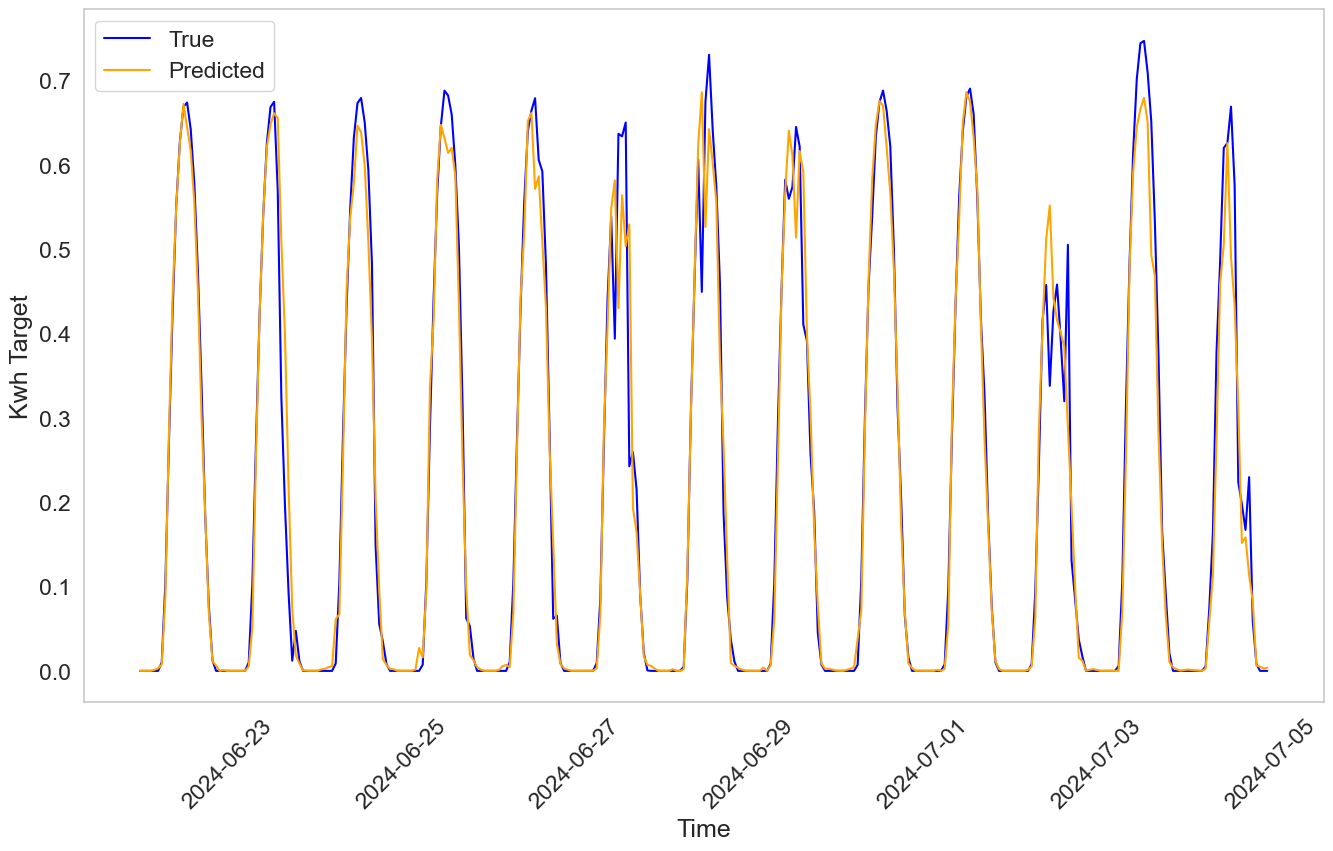

In [21]:
last_312_df = results_df.tail(312)
sns.set_style("whitegrid")

plt.figure(figsize=(16, 9))
sns.set_context("notebook", font_scale=1.5)
sns.lineplot(x=last_312_df.index, y=last_312_df['True'], label='True', color='blue')
sns.lineplot(x=last_312_df.index, y=last_312_df['Predicted'], label='Predicted', color='orange')
plt.xlabel('Time')
plt.ylabel('Kwh Target')
#plt.title('Predicted vs Actual Kwh Target')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [22]:
r2_score(y_pred_flat, y_test_flat)   #0.94332

0.9418769999636294

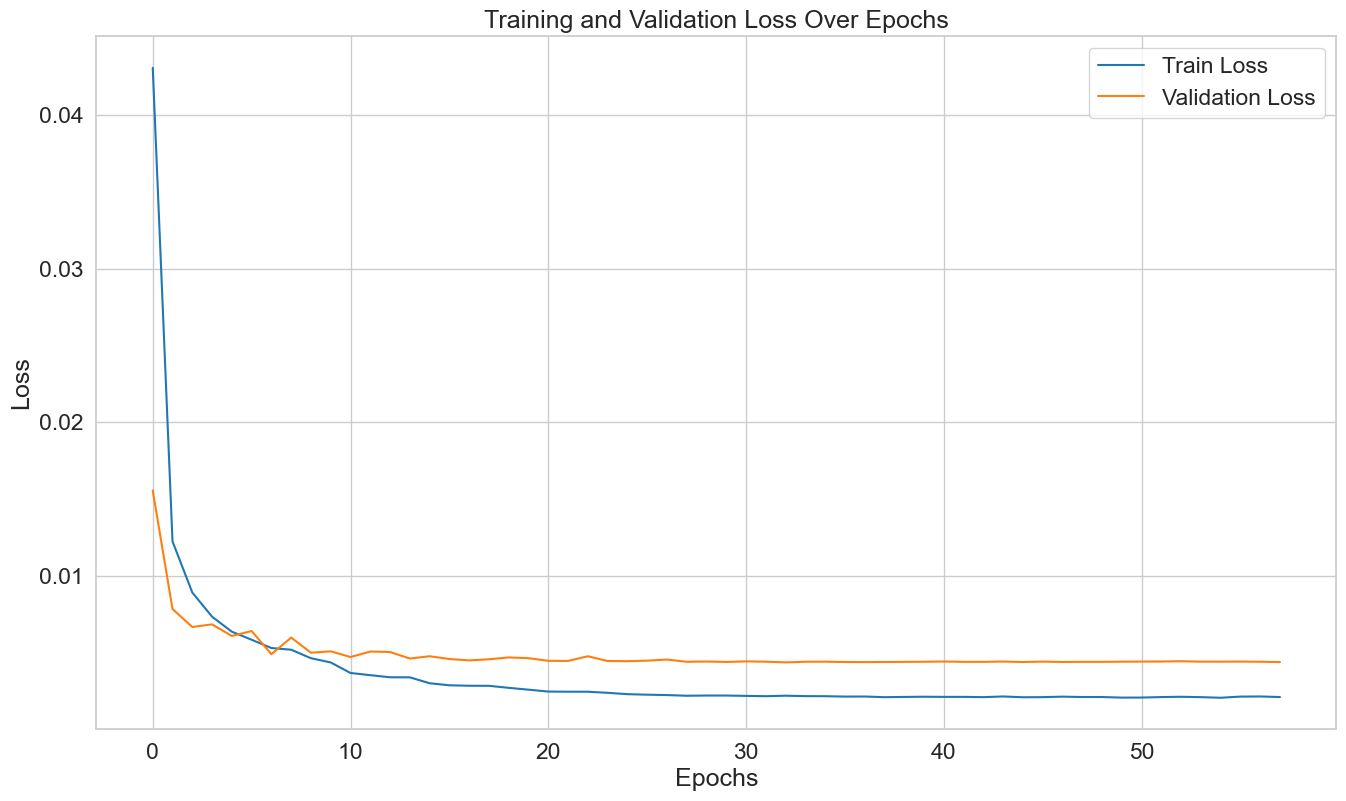

In [23]:
plt.figure(figsize = (16, 9))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

<Axes: >

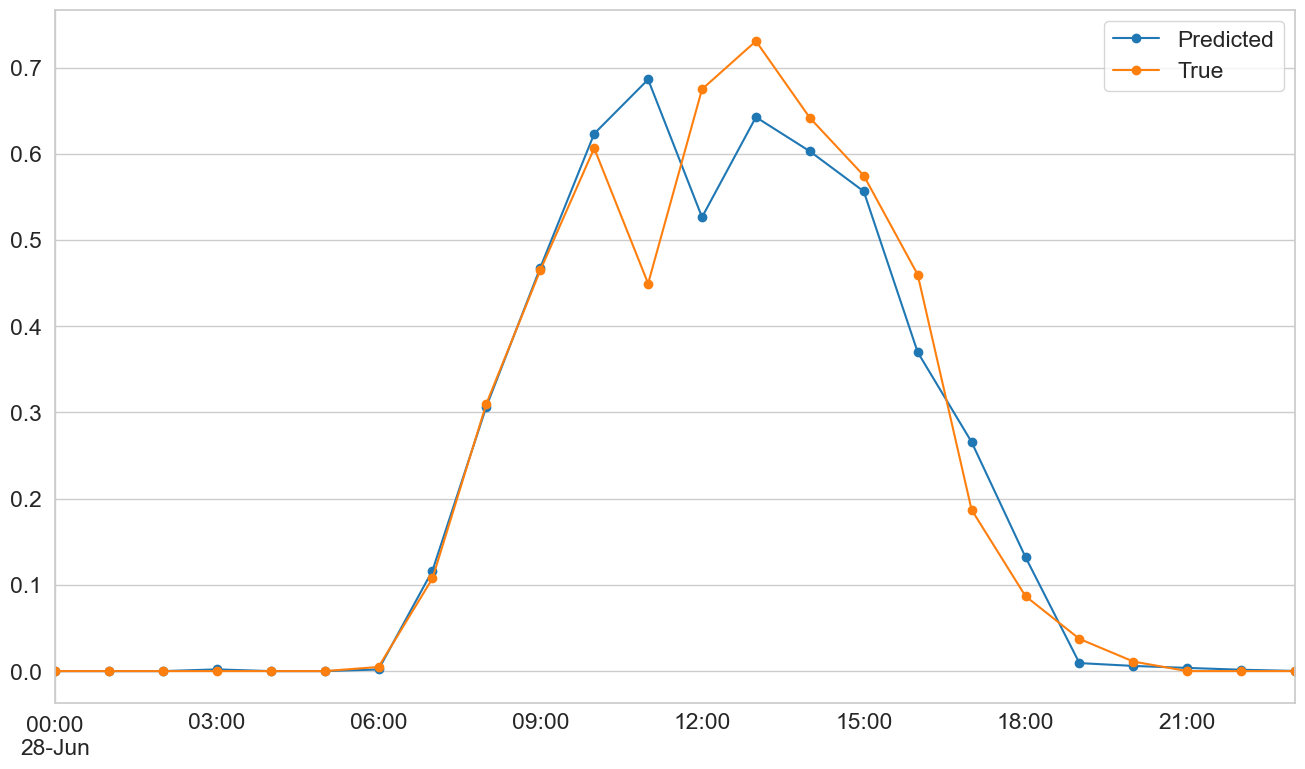

In [24]:
sns.set_context("notebook", font_scale=1.5)
sns.set_style("whitegrid")
results_df[-168: - 144].plot(figsize=(16, 9), marker = 'o')

In [25]:
mean_squared_error(results_df[-168: - 144]['Predicted'], 
                   results_df[-168: - 144]['True'])

0.004384514594462001

In [26]:
r2_score(results_df[-168: - 144]['Predicted'], 
         results_df[-168: - 144]['True'])

0.9339918906741712

<Axes: >

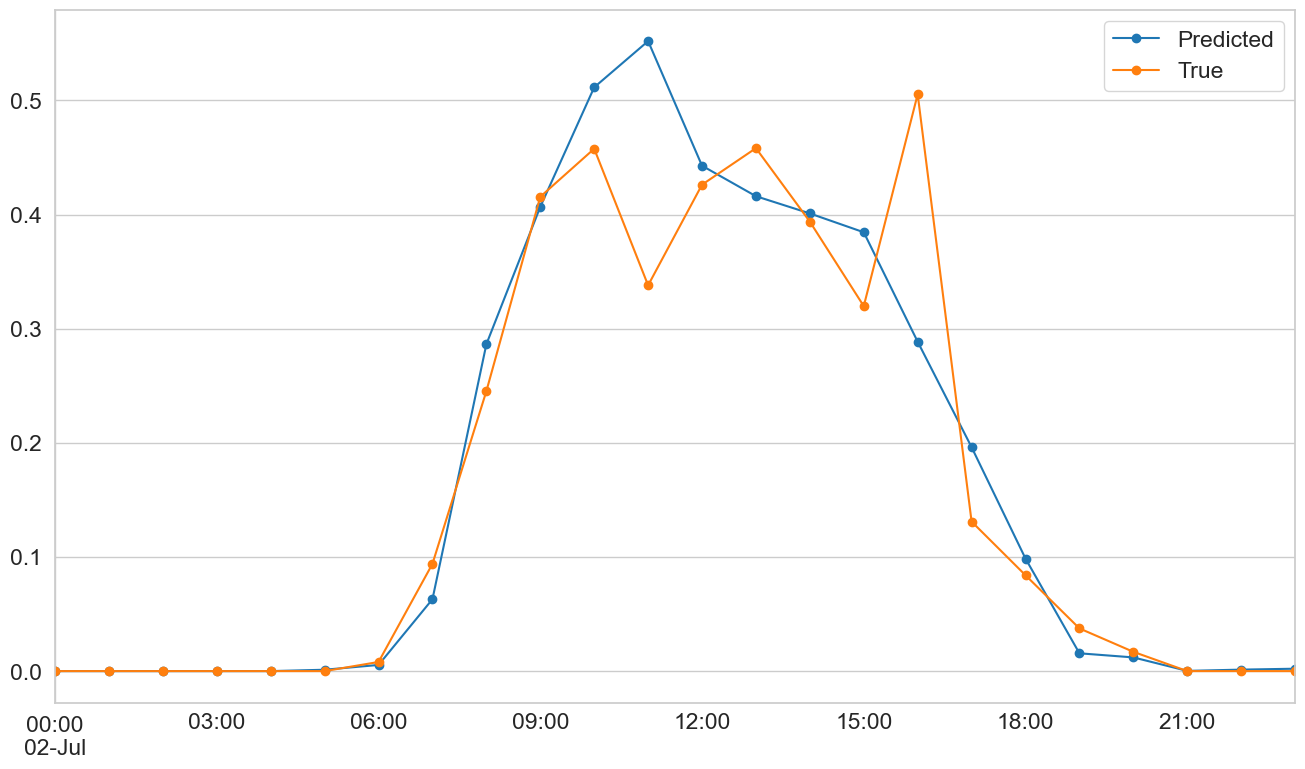

In [27]:
results_df[-72: -48].plot(figsize= (16, 9), marker = "o")

In [28]:
mean_squared_error(results_df[-72: -48]['Predicted'], results_df[-72: -48]['True'])

0.004570167227615859

In [29]:
r2_score(results_df[-72: -48]['Predicted'], results_df[-72: -48]['True'])

0.8823380362479892

# Weather Analysis of the predictions

In [30]:
results_df

,Predicted,True
2024-05-20 05:00:00,0.0023,0.0000
2024-05-20 06:00:00,0.0066,0.0016
2024-05-20 07:00:00,0.0583,0.0463
2024-05-20 08:00:00,0.2259,0.1792
2024-05-20 09:00:00,0.3197,0.4355
...,...,...
2024-07-04 19:00:00,0.0824,0.0592
2024-07-04 20:00:00,0.0064,0.0085
2024-07-04 21:00:00,0.0050,0.0000
2024-07-04 22:00:00,0.0026,0.0000


In [31]:
results_df = results_df.tail(-19)
results_df

,Predicted,True
2024-05-21 00:00:00,0.0000,0.0000
2024-05-21 01:00:00,0.0000,0.0000
2024-05-21 02:00:00,0.0000,0.0000
2024-05-21 03:00:00,0.0000,0.0000
2024-05-21 04:00:00,0.0000,0.0000
...,...,...
2024-07-04 19:00:00,0.0824,0.0592
2024-07-04 20:00:00,0.0064,0.0085
2024-07-04 21:00:00,0.0050,0.0000
2024-07-04 22:00:00,0.0026,0.0000


In [32]:
common_index = kwh_data.index.intersection(results_df.index)
common_index

DatetimeIndex(['2024-05-21 00:00:00', '2024-05-21 01:00:00',
               '2024-05-21 02:00:00', '2024-05-21 03:00:00',
               '2024-05-21 04:00:00', '2024-05-21 05:00:00',
               '2024-05-21 06:00:00', '2024-05-21 07:00:00',
               '2024-05-21 08:00:00', '2024-05-21 09:00:00',
               ...
               '2024-07-04 14:00:00', '2024-07-04 15:00:00',
               '2024-07-04 16:00:00', '2024-07-04 17:00:00',
               '2024-07-04 18:00:00', '2024-07-04 19:00:00',
               '2024-07-04 20:00:00', '2024-07-04 21:00:00',
               '2024-07-04 22:00:00', '2024-07-04 23:00:00'],
              dtype='datetime64[ns]', length=1080, freq='H')

In [33]:
data_cleaned = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= 'datetime', parse_dates= True)
data_cleaned

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0000,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0000,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0000,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0000,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0000,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,0.0592,"Kozani, Greece",24.0,24.0,10.0,41.15,0.0,0.0,0.0,22.0,9.4,180.0,1010.0,79.3,NaN,207.0,0.7,2.0,Partially cloudy,partly-cloudy-day
2024-07-04 20:00:00,0.0085,"Kozani, Greece",23.0,23.0,9.0,40.87,0.1,0.0,0.0,22.0,3.6,172.8,1010.0,81.7,NaN,103.0,0.4,1.0,"Rain, Partially cloudy",rain
2024-07-04 21:00:00,0.0000,"Kozani, Greece",21.0,21.0,10.0,49.39,0.1,0.0,0.0,14.4,0.0,0.0,1011.0,63.7,NaN,9.0,0.0,0.0,"Rain, Partially cloudy",rain


In [34]:
data_cleaned_same_index = data_cleaned.loc[common_index]
data_cleaned_same_index

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
2024-05-21 00:00:00,0.0000,"Kozani, Greece",17.0,17.0,15.0,88.00,0.0,0.0,0.0,13.5,5.4,160.0,1016.0,65.4,5.7,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2024-05-21 01:00:00,0.0000,"Kozani, Greece",16.0,16.0,15.0,93.79,0.0,0.0,0.0,5.0,3.6,342.4,1016.0,94.1,1.9,0.0,0.0,0.0,Overcast,cloudy
2024-05-21 02:00:00,0.0000,"Kozani, Greece",16.0,16.0,15.0,93.79,0.0,0.0,0.0,4.7,3.6,350.2,1016.0,100.0,15.4,0.0,0.0,0.0,Overcast,cloudy
2024-05-21 03:00:00,0.0000,"Kozani, Greece",15.0,15.0,14.0,93.72,0.0,0.0,0.0,15.3,5.4,237.0,1016.0,84.3,15.3,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2024-05-21 04:00:00,0.0000,"Kozani, Greece",14.0,14.0,14.0,100.00,0.0,0.0,0.0,6.8,5.4,350.2,1016.0,38.7,16.8,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,0.0592,"Kozani, Greece",24.0,24.0,10.0,41.15,0.0,0.0,0.0,22.0,9.4,180.0,1010.0,79.3,NaN,207.0,0.7,2.0,Partially cloudy,partly-cloudy-day
2024-07-04 20:00:00,0.0085,"Kozani, Greece",23.0,23.0,9.0,40.87,0.1,0.0,0.0,22.0,3.6,172.8,1010.0,81.7,NaN,103.0,0.4,1.0,"Rain, Partially cloudy",rain
2024-07-04 21:00:00,0.0000,"Kozani, Greece",21.0,21.0,10.0,49.39,0.1,0.0,0.0,14.4,0.0,0.0,1011.0,63.7,NaN,9.0,0.0,0.0,"Rain, Partially cloudy",rain
2024-07-04 22:00:00,0.0000,"Kozani, Greece",20.0,20.0,11.0,56.15,0.0,0.0,0.0,14.0,0.0,0.0,1012.0,65.5,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [35]:
eval_df = pd.concat([data_cleaned_same_index["conditions"], results_df], axis= 1)
eval_df

,conditions,Predicted,True
2024-05-21 00:00:00,Partially cloudy,0.0000,0.0000
2024-05-21 01:00:00,Overcast,0.0000,0.0000
2024-05-21 02:00:00,Overcast,0.0000,0.0000
2024-05-21 03:00:00,Partially cloudy,0.0000,0.0000
2024-05-21 04:00:00,Partially cloudy,0.0000,0.0000
...,...,...,...
2024-07-04 19:00:00,Partially cloudy,0.0824,0.0592
2024-07-04 20:00:00,"Rain, Partially cloudy",0.0064,0.0085
2024-07-04 21:00:00,"Rain, Partially cloudy",0.0050,0.0000
2024-07-04 22:00:00,Partially cloudy,0.0026,0.0000


In [36]:
def categorize_condition(condition):
    if "Rain" in condition:
        return "Rain"
    elif "Clear" in condition:
        return "Clear"
    else:
        return "Cloudy"
    
    

eval_df["conditions_class"] = eval_df["conditions"].apply(categorize_condition)
eval_df

,conditions,Predicted,True,conditions_class
2024-05-21 00:00:00,Partially cloudy,0.0000,0.0000,Cloudy
2024-05-21 01:00:00,Overcast,0.0000,0.0000,Cloudy
2024-05-21 02:00:00,Overcast,0.0000,0.0000,Cloudy
2024-05-21 03:00:00,Partially cloudy,0.0000,0.0000,Cloudy
2024-05-21 04:00:00,Partially cloudy,0.0000,0.0000,Cloudy
...,...,...,...,...
2024-07-04 19:00:00,Partially cloudy,0.0824,0.0592,Cloudy
2024-07-04 20:00:00,"Rain, Partially cloudy",0.0064,0.0085,Rain
2024-07-04 21:00:00,"Rain, Partially cloudy",0.0050,0.0000,Rain
2024-07-04 22:00:00,Partially cloudy,0.0026,0.0000,Cloudy


In [37]:
eval_df = eval_df.drop('conditions', axis=1)
eval_df

,Predicted,True,conditions_class
2024-05-21 00:00:00,0.0000,0.0000,Cloudy
2024-05-21 01:00:00,0.0000,0.0000,Cloudy
2024-05-21 02:00:00,0.0000,0.0000,Cloudy
2024-05-21 03:00:00,0.0000,0.0000,Cloudy
2024-05-21 04:00:00,0.0000,0.0000,Cloudy
...,...,...,...
2024-07-04 19:00:00,0.0824,0.0592,Cloudy
2024-07-04 20:00:00,0.0064,0.0085,Rain
2024-07-04 21:00:00,0.0050,0.0000,Rain
2024-07-04 22:00:00,0.0026,0.0000,Cloudy


In [38]:
eval_df['team'] = (eval_df.reset_index().index // 24) + 1  
eval_df

,Predicted,True,conditions_class,team
2024-05-21 00:00:00,0.0000,0.0000,Cloudy,1
2024-05-21 01:00:00,0.0000,0.0000,Cloudy,1
2024-05-21 02:00:00,0.0000,0.0000,Cloudy,1
2024-05-21 03:00:00,0.0000,0.0000,Cloudy,1
2024-05-21 04:00:00,0.0000,0.0000,Cloudy,1
...,...,...,...,...
2024-07-04 19:00:00,0.0824,0.0592,Cloudy,45
2024-07-04 20:00:00,0.0064,0.0085,Rain,45
2024-07-04 21:00:00,0.0050,0.0000,Rain,45
2024-07-04 22:00:00,0.0026,0.0000,Cloudy,45


In [39]:
eval_df_non_zero = eval_df[eval_df['True'] != 0]
eval_df_non_zero

,Predicted,True,conditions_class,team
2024-05-21 06:00:00,0.0000,0.0043,Cloudy,1
2024-05-21 07:00:00,0.0655,0.0643,Cloudy,1
2024-05-21 08:00:00,0.2185,0.2481,Cloudy,1
2024-05-21 09:00:00,0.3785,0.4276,Cloudy,1
2024-05-21 10:00:00,0.5034,0.5608,Cloudy,1
...,...,...,...,...
2024-07-04 16:00:00,0.1518,0.1976,Cloudy,45
2024-07-04 17:00:00,0.1584,0.1672,Cloudy,45
2024-07-04 18:00:00,0.1134,0.2298,Rain,45
2024-07-04 19:00:00,0.0824,0.0592,Cloudy,45


In [40]:
cloudy_eval_df_non_zero = eval_df_non_zero[eval_df_non_zero['conditions_class'] == "Cloudy"]
cloudy_eval_df_non_zero.head()

,Predicted,True,conditions_class,team
2024-05-21 06:00:00,0.0000,0.0043,Cloudy,1
2024-05-21 07:00:00,0.0655,0.0643,Cloudy,1
2024-05-21 08:00:00,0.2185,0.2481,Cloudy,1
2024-05-21 09:00:00,0.3785,0.4276,Cloudy,1
2024-05-21 10:00:00,0.5034,0.5608,Cloudy,1


In [41]:
cloudy_data_frame_grouped = cloudy_eval_df_non_zero['conditions_class'].groupby(cloudy_eval_df_non_zero.index.date).value_counts() > 3
cloudy_data_frame_grouped

            conditions_class
2024-05-21  Cloudy               True
2024-05-22  Cloudy               True
2024-05-23  Cloudy               True
2024-05-24  Cloudy               True
2024-05-25  Cloudy               True
2024-05-26  Cloudy               True
2024-05-27  Cloudy               True
2024-05-28  Cloudy               True
2024-05-29  Cloudy               True
2024-05-30  Cloudy               True
2024-05-31  Cloudy               True
2024-06-01  Cloudy               True
2024-06-02  Cloudy               True
2024-06-03  Cloudy               True
2024-06-04  Cloudy               True
2024-06-05  Cloudy               True
2024-06-06  Cloudy               True
2024-06-07  Cloudy               True
2024-06-08  Cloudy               True
2024-06-09  Cloudy               True
2024-06-10  Cloudy               True
2024-06-11  Cloudy               True
2024-06-12  Cloudy               True
2024-06-13  Cloudy               True
2024-06-14  Cloudy               True
2024-06-15  Cloudy   

In [42]:
cloudy_data_frame_grouped.value_counts()

count
True     44
False     1
Name: count, dtype: int64

In [43]:
daily_r2_scores = {}
grouped = eval_df.groupby(eval_df.index.date)  

for date, group in grouped:
    r2 = r2_score(group["True"], group["Predicted"])
    daily_r2_scores[date] = r2
    
r2_df = pd.DataFrame(list(daily_r2_scores.items()), columns=["Date", "R2_Score"])
print(r2_df)


          Date  R2_Score
0   2024-05-21  0.962403
1   2024-05-22  0.984986
2   2024-05-23  0.959083
3   2024-05-24  0.978125
4   2024-05-25  0.831347
5   2024-05-26  0.851150
6   2024-05-27  0.926986
7   2024-05-28  0.818525
8   2024-05-29  0.796637
9   2024-05-30  0.812576
10  2024-05-31  0.942683
11  2024-06-01  0.979509
12  2024-06-02  0.978455
13  2024-06-03  0.788830
14  2024-06-04  0.982028
15  2024-06-05  0.940555
16  2024-06-06  0.931432
17  2024-06-07  0.983863
18  2024-06-08  0.979577
19  2024-06-09  0.987377
20  2024-06-10  0.860191
21  2024-06-11  0.969048
22  2024-06-12  0.978686
23  2024-06-13  0.740900
24  2024-06-14  0.982681
25  2024-06-15  0.988320
26  2024-06-16  0.970358
27  2024-06-17  0.856969
28  2024-06-18  0.985028
29  2024-06-19  0.977835
30  2024-06-20  0.996538
31  2024-06-21  0.990572
32  2024-06-22  0.997099
33  2024-06-23  0.926904
34  2024-06-24  0.980443
35  2024-06-25  0.985809
36  2024-06-26  0.979684
37  2024-06-27  0.848855
38  2024-06-28  0.937707


In [69]:
filtered_data = data_cleaned.loc[data_cleaned.index.strftime('%Y-%m-%d') == "2024-06-28", 'cloudcover']
print(filtered_data)


datetime
2024-06-28 00:00:00    67.6
2024-06-28 01:00:00    19.1
2024-06-28 02:00:00     3.7
2024-06-28 03:00:00     0.0
2024-06-28 04:00:00     0.0
2024-06-28 05:00:00    14.3
2024-06-28 06:00:00     0.0
2024-06-28 07:00:00    46.8
2024-06-28 08:00:00     0.0
2024-06-28 09:00:00    25.6
2024-06-28 10:00:00    25.7
2024-06-28 11:00:00    25.7
2024-06-28 12:00:00    49.9
2024-06-28 13:00:00    50.0
2024-06-28 14:00:00    50.0
2024-06-28 15:00:00    50.0
2024-06-28 16:00:00    64.0
2024-06-28 17:00:00    78.1
2024-06-28 18:00:00    69.6
2024-06-28 19:00:00    77.0
2024-06-28 20:00:00    50.4
2024-06-28 21:00:00    40.0
2024-06-28 22:00:00     0.0
2024-06-28 23:00:00    10.2
Name: cloudcover, dtype: float64


<Axes: xlabel='datetime'>

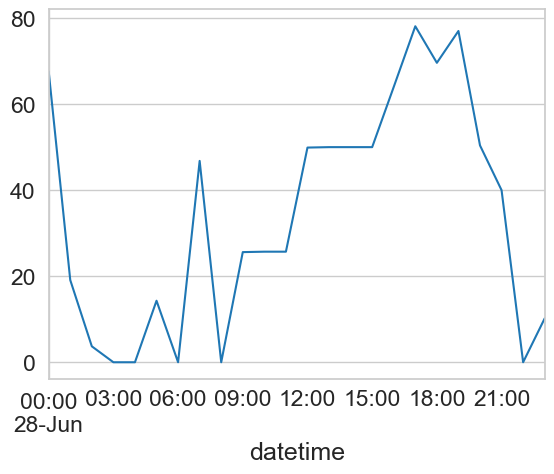

In [70]:
filtered_data.plot()